In [28]:
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import(
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBRegressor

In [13]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/proyecto-auto-mpg'
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Drive montado y entorno listo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado y entorno listo


* Cargamos los splits ya preparados por el notebook de EDA: train_raw y test_raw: sin escalar.

In [14]:
train = pd.read_csv(f'{PROJECT}/data/train_raw.csv')
test  = pd.read_csv(f'{PROJECT}/data/test_raw.csv')

X_train = train.drop('mpg', axis=1)
y_train = train['mpg']

X_test  = test.drop('mpg', axis=1)
y_test  = test['mpg']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Columnas: {list(X_train.columns)}")

Train: (318, 8) | Test: (80, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']


* Los modelos de árboles (AdaBoost, XGBoost) no necesitan escalado porque no calculan distancias ni penalizaciones, tal que, solo hacen divisiones binarias sobre los valores. Usar los datos sin escalar además facilita la interpretación de las importancias de variables en sus unidades originales.

+ **AdaBoost**

Queremos aproximar las millas por galón según características mecánicas de los autos.
+ queremos hacer que:

$$mpg = f(x_1, x_1, x_3, ... , x_n )$$

Definimos nuestro arbol base

In [15]:
arbol_base = DecisionTreeRegressor(max_depth=5, random_state = 42)

+ Definimos el modelo ADA

In [16]:
ADA = AdaBoostRegressor(
    estimator = arbol_base,
    n_estimators= 500,
    learning_rate = 0.07,
    random_state=42
)

+ Entrenamiento

In [18]:
ADA.fit(X_train, y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
                  learning_rate=0.07, n_estimators=500, random_state=42)

+ Predicciones

In [20]:
y_pred_ada = ADA.predict(X_test)
#print(y_pred_ada)

[31.25       30.28125    20.6        15.13333333 14.375      26.06578947
 27.496      12.125      17.76       20.03448276 14.23529412 35.13285714
 28.125      14.64285714 24.32608696 13.         30.54444444 19.78181818
 15.5        35.73333333 23.96       19.95       29.92692308 29.44117647
 15.66666667 37.05238095 24.61111111 23.39166667 18.76666667 13.
 28.378      34.15454545 17.60833333 24.64716981 37.1125     13.75
 22.04545455 17.73333333 14.17567568 25.59       27.62       27.4
 21.30434783 12.         23.27073171 34.98333333 25.65625    22.73571429
 24.50697674 26.35294118 22.74444444 33.94333333 33.56555556 13.
 27.7        13.52941176 17.05       28.21666667 23.51666667 18.9
 14.85714286 31.         23.45       21.11714286 19.89285714 24.82826087
 22.83529412 34.28617021 27.46153846 14.59090909 34.34222222 14.44318182
 13.52631579 19.08333333 27.496      19.6        18.60833333 29.7
 28.5        17.6       ]


+ Evaluaremos el modelo mediante **RME**, **LMSE** Y **$R^2$**

In [24]:
mse_ADA =mean_squared_error(
    y_test,
    y_pred_ada
)

rmse_ADA = np.sqrt(mse_ADA)

r2_ADA = r2_score(
    y_test,
    y_pred_ada
)

print(f'RMSE : {rmse_ADA}')
print(f'MSE: {mse_ADA}')
print(f'R2: {r2_ADA}')

RMSE : 2.2487826190228963
MSE: 5.057023267619478
R2: 0.9059446205679267


+ Pequeña visualización

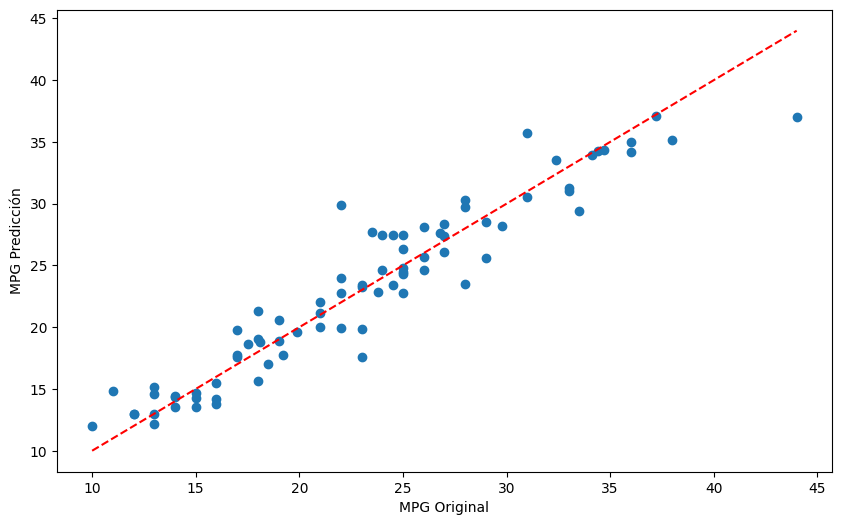

In [69]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_ada)
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('MPG Original')
plt.ylabel('MPG Predicción')
plt.savefig(f'{PROJECT}/figures/prediccion_ada_base.png',
            bbox_inches='tight')
plt.show()

+ Vamos con **XGBoost**

+ Definimos el modelo junto con sus hiperparámetros

In [32]:

XGB = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,

    min_child_weight = 5, #evita crear hojas con pocas observaciones
    gamma = 0.1, #exige una reducción minima del error al crear una nueva división

    #early_stopping_rounds = 5, #evita sobreajuste

    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,

    reg_alpha = 0.1,
    reg_lambda = 1.0,

    random_state = 42
                    )

+ Entrenamiento XGB "empírico".

In [33]:
XGB.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

+ Prediccion

In [34]:
Y_pred_xgb = XGB.predict(X_test)
#print(Y_pred_xgb)

+ Evaluamos el modelo mediante **MSE**, **RMSE** y $R^2$

In [35]:
mse_xgb = mean_squared_error(
    y_test,
    Y_pred_xgb
)

rmse_xgb = np.sqrt(mse_xgb)

r2_xgb = r2_score(
    y_test, Y_pred_xgb
)

print(f'MSE:{mse_xgb}')
print(f'RMSE: {rmse_xgb}')
print(f'R^2: {r2_xgb}')

MSE:5.117726981015631
RMSE: 2.2622393730583927
R^2: 0.9048155945590947


+ Visualización

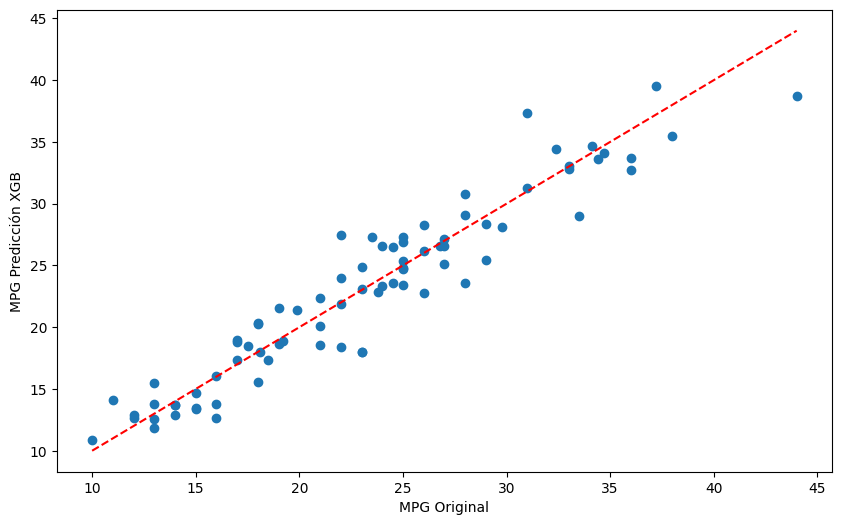

In [68]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, Y_pred_xgb)
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('MPG Original')
plt.ylabel('MPG Predicción XGB')
plt.savefig(f'{PROJECT}/figures/prediccion_xgb_base.png',
            bbox_inches='tight')
plt.show()

------------------------------------------------
------------------------------------------------------------------------------------------------

+ **CROSS VALIDATION PARA XGBOOST**

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [38]:
cross_fold = KFold(n_splits = 5, shuffle=True, random_state=42)

+ Buscaremos hiperparámetros automáticamente  

In [39]:
from sklearn.model_selection import GridSearchCV

+ Definimos la rejilla de parámetros

In [40]:
params_XGB = {
    'max_depth' : [3,4,5],
    'learning_rate' : [0.01, 0.05, 0.07],
    'n_estimators' : [200, 300, 400],
    'reg_alpha' : [0.01, 0.03, 0.04],
    'reg_lambda' : [1.0, 3.0, 4.0],
    'gamma' : [0.1, 0.2,0.3],
    #'min_child_weight' : [3, 5, 6]
}

#creamos el modelo

model_XGB = XGBRegressor(
    subsample =0.8,
    colsample_bytree = 0.8,
    random_state=42
)

#ejecutamos el modelo

grid_XGB = GridSearchCV(
    estimator = model_XGB,
    param_grid = params_XGB,
    cv = 5,
    scoring='r2',
    n_jobs = -1
)

#entrenamos

grid_XGB.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0.1, 0.2, 0.3],
                         'learning_rate': [0.01, 0.05, 0.07],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [200, 300, 400],
                         'reg_alpha': [0.01, 0.03, 0.04],
                         'reg_lambda': [1.0, 3.0, 4.0]},
             scoring='r2')

+ vemos los mejores parámtros

In [41]:
print(grid_XGB.best_params_)

{'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.01, 'reg_lambda': 4.0}


+ entrenamos el mejor modelo

In [42]:
best_xgb_grid = grid_XGB.best_estimator_

+ veamos sus parámetros

In [43]:
print(best_xgb_grid)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


+ Vamos a hacer predicciones y evaluar las métricas

In [44]:
y_pred_XGB_grid = best_xgb_grid.predict(X_test)

mse_grid = mean_squared_error(y_test, y_pred_XGB_grid)
rmse_grid = mse_grid**0.5
r2_grid = r2_score(y_test, y_pred_XGB_grid)

print(f'RMSE: {rmse_grid}')
print(f'MSE: {mse_grid}')
print(f'R2: {r2_grid}')

RMSE: 2.321099160340311
MSE: 5.387501312132498
R2: 0.8997980722477578


+ Visualización de XGB mediante cross validation

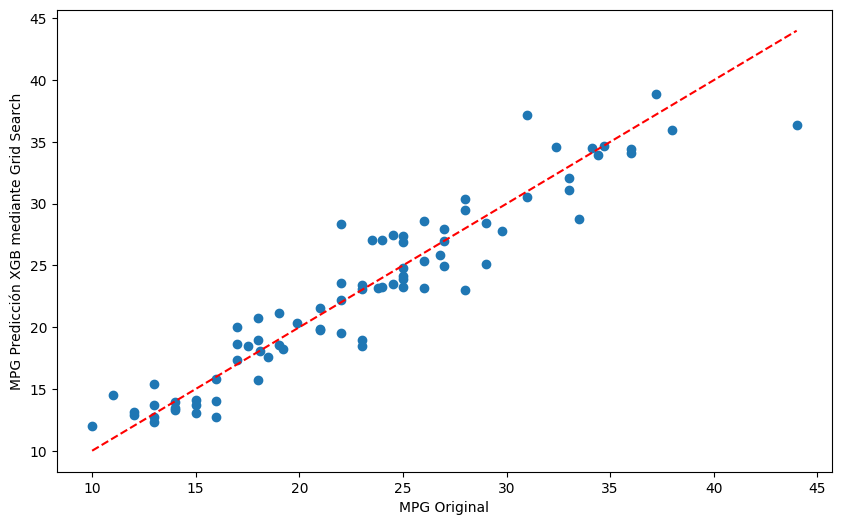

In [67]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_XGB_grid)
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('MPG Original')
plt.ylabel('MPG Predicción XGB mediante Grid Search')
plt.savefig(f'{PROJECT}/figures/Prediccion_XGB_GS',
            bbox_inches='tight')
plt.show()

**CROSS VALIDATION PARA ADABOOST**

+ La idea al hacer gridsearch con adaboost es la misma que para xgboost

+ Ya habiamos definido un arbol base y un modelo __ADA__

Definimos la rejilla de parámtros

In [46]:
param_grid_ADA = {
    'estimator__max_depth' : [3,4,5],
    'n_estimators' : [200, 300, 400],
    'learning_rate' : [0.02, 0.04, 0.05],
    'loss' : ['linear', 'square']
}

+ Ya habíamos definido la validación cruzada y el modelo ADA

In [47]:
grid_ADA = GridSearchCV(
    estimator = ADA,
    param_grid = param_grid_ADA,
    cv = cross_fold,
    scoring = 'r2',
    n_jobs = -1
)

+ Entrenamos el modelo

In [48]:
grid_ADA.fit(X_train, y_train) #tarda aprox 2 mins en correr

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                                         random_state=42),
                                         learning_rate=0.07, n_estimators=500,
                                         random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [3, 4, 5],
                         'learning_rate': [0.02, 0.04, 0.05],
                         'loss': ['linear', 'square'],
                         'n_estimators': [200, 300, 400]},
             scoring='r2')

In [50]:
print(grid_ADA.best_params_)

best_ADA_grid = grid_ADA.best_estimator_

{'estimator__max_depth': 5, 'learning_rate': 0.05, 'loss': 'linear', 'n_estimators': 300}


+ Recuperamos el modelo con mejores parámetros segun el grid search

In [51]:
#prediccion
pred_ADA_grid = best_ADA_grid.predict(X_test)

+ Calculo de las métricas

In [54]:
#y_pred_ADA_grid = best_ADA_grid.predict(X_test)

mse_grid_ada = mean_squared_error(y_test, pred_ADA_grid)
rmse_grid_ada = mse_grid_ada**0.5
r2_grid_ada = r2_score(y_test, pred_ADA_grid)

print(f'RMSE: {rmse_grid_ada}')
print(f'MSE: {mse_grid_ada}')
print(f'R2: {r2_grid_ada}')

RMSE: 2.2466583568591294
MSE: 5.047473772444964
R2: 0.9061222312579496


+ Visualización de AdaBoost mediante Cross Validation

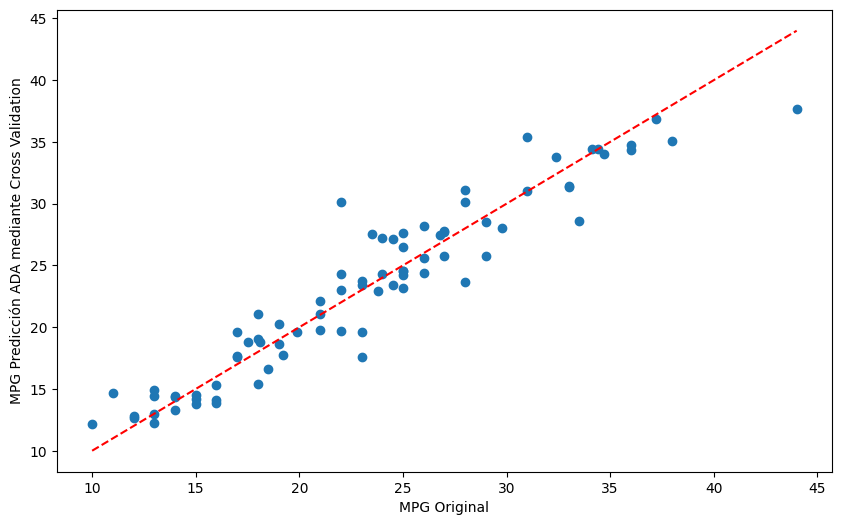

In [65]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, pred_ADA_grid)
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('MPG Original')
plt.ylabel('MPG Predicción ADA mediante Cross Validation')
plt.savefig(f'{PROJECT}/figures/Prediccion_ADA',
            bbox_inches='tight')
plt.show()

+ Importancia de Features según cada modelo


In [70]:
# creamos un DF con las importancias de AdaBoost

dfAda_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_ADA_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)

#creamos un df con las importancias de XGBoost

dfXGB_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_xgb_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)


+ Graficación de importance features

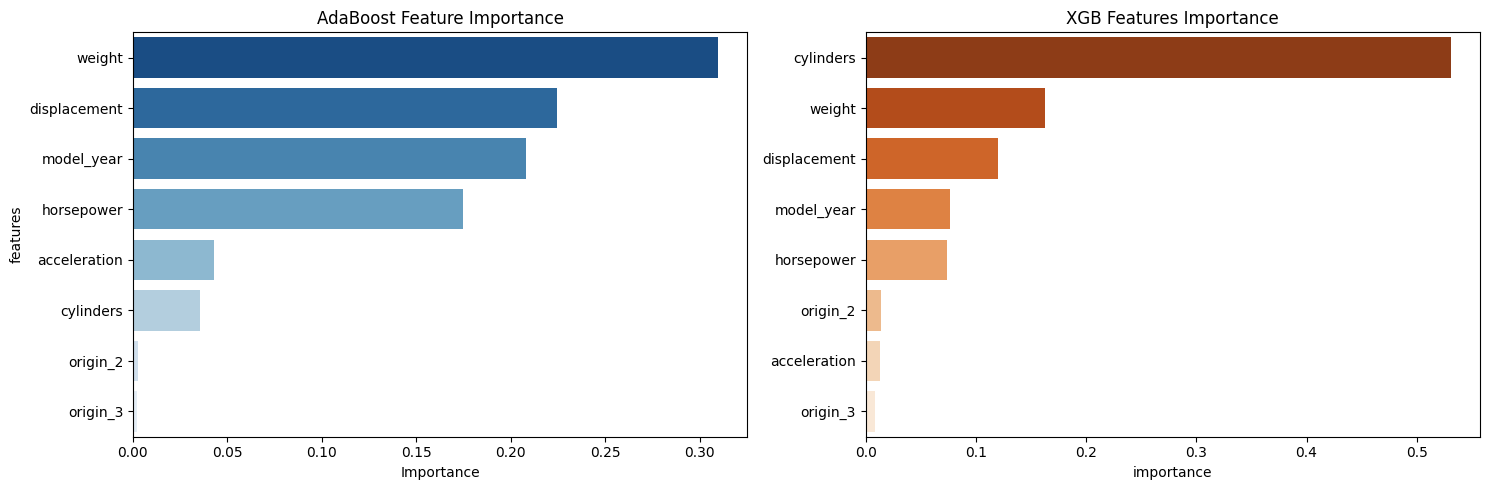

In [71]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

#graf para Ada
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')

#graf para XGB
sns.barplot(x = 'importance', y = 'feature', hue= 'feature', data = dfXGB_features_imp, ax=axes[1], palette = 'Oranges_r')
axes[1].set_title('XGB Features Importance')
axes[1].set_xlabel('importance')
axes[1].set_ylabel('')

#graf para ada por cross validation
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')


#plot
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/importancias_ADA_XGB.png',
            bbox_inches='tight')
plt.show()

Las importancias de las features evaluadas por AdaBoost y por XGB son diferentes. Sin embargo, las variables con mayor importancia, elegidas por cada modelo, parecen estar dentro de la lógica del problema, pues un mayor peso requerirá mayor consumo de combustible, así como un mayor cilindraje, requerirá un mayor consumo.

+ La diferencia en la evaluación del nivel de importancia es normal:

+ *AdaBoost* calcula la importancia usando el coeficiente ´gini importance´ o el ´mean decrece in impurity (MDI)´. Mide qué tanto ayudan las características a purificar los nodos de los árboles de decisión que se van creando.

+ *XGBoost* utiliza el coeficiente ´gain´ y mide la meora relatica en la precisión que aporta cada caracterísitica al ser introducida en las ramas del árbol.


+ Hagamos una comparación de los resultados obtenidos con cada modelo:


In [72]:
evaluacion = pd.DataFrame({
    "modelo" : ["AdaBoost", "XGBoost", "AdaBoost CV", "XGB CV"],
    "MSE" : [mse_ADA, mse_xgb, mse_grid_ada, mse_grid],
    "RMSE" : [rmse_ADA, rmse_xgb, rmse_grid_ada, rmse_grid],
    "R^2" : [r2_ADA, r2_xgb, r2_grid_ada, r2_grid]
})
print(evaluacion)

        modelo       MSE      RMSE       R^2
0     AdaBoost  5.057023  2.248783  0.905945
1      XGBoost  5.117727  2.262239  0.904816
2  AdaBoost CV  5.047474  2.246658  0.906122
3       XGB CV  5.387501  2.321099  0.899798


+ Al implementar hiperparámetros ajustados según el tipo de problema tratado, encontramos una mejoría en XGB respecto a ADA. Los parámetros clave incorporados en esta mejoría fueron *reg_alpha=0.1*, *reg_lambda = 1.0*, *gamma=1.0* y *min_child_weight = 5*. Al incorporar estos hiperparámetros en XGB, los coeficientes de evaluación mejoraron y son similares a los obtenidos con ADA.

* Por ultimo, guardamos las metricas finales en un csv

In [63]:
# Guardar métricas en Drive para comparativa final
evaluacion.to_csv(f'{PROJECT}/data/metricas_boosting.csv', index=False)

# Verificar guardado
import os
print("Archivos en data/:")
for a in sorted(os.listdir(f'{PROJECT}/data')):
    if not a.startswith('.'):
        print(f"  - {a}")

Archivos en data/:
  - auto_mpg_clean.csv
  - auto_mpg_clean.gsheet
  - metricas_boosting.csv
  - scaler.pkl
  - test_raw.csv
  - test_scaled.csv
  - train_raw.csv
  - train_scaled.csv
